Gathering historical data using yfinance package first.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

start_date = '2023-01-03'
end_date = '2026-2-23'

stock = "INTC"
index = "SPY"

# Downloading data
stock_data = yf.download(stock, start=start_date, end=end_date)
index_data = yf.download(index, start=start_date, end=end_date)

stock_data.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INTC,INTC,INTC,INTC,INTC
Date,,,,,
2023-01-03,25.775145,26.102999,25.428006,26.083713,31308000
2023-01-04,26.691210,26.922636,26.189785,26.430854,37665200
2023-01-05,26.575499,26.787641,26.401928,26.459786,33552600
2023-01-06,27.703699,27.800127,26.401924,26.932278,31788600
2023-01-09,28.262981,28.802978,27.809772,27.809772,37493200


In [7]:
stock_log_ret = stock_data['Close'].apply(lambda x: np.log(x)).diff()
index_log_ret = index_data['Close'].apply(lambda x: np.log(x)).diff()

stock_log_ret = stock_log_ret.dropna()
index_log_ret = index_log_ret.dropna()

stock_log_ret.head()

Ticker,INTC
Date,
2023-01-04,0.034924
2023-01-05,-0.004345
2023-01-06,0.041576
2023-01-09,0.019987
2023-01-10,0.004426


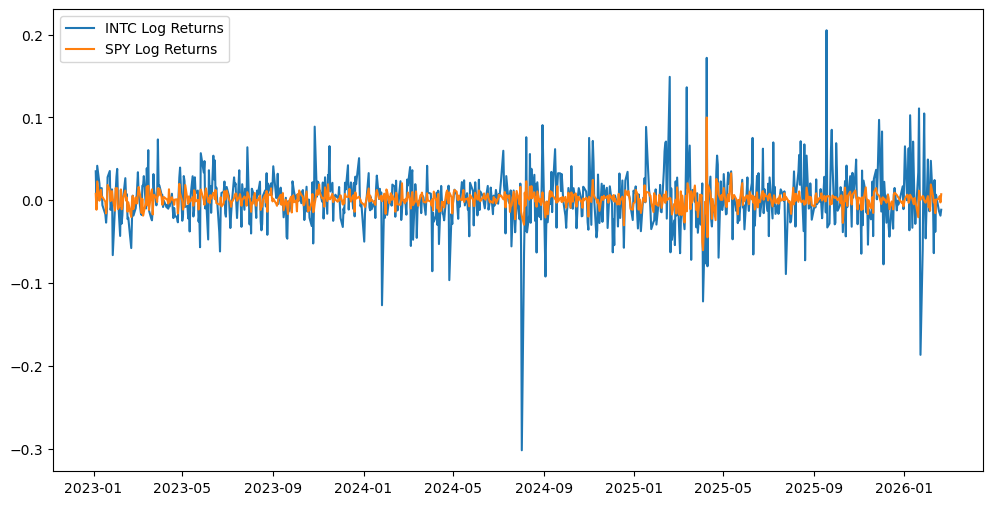

In [8]:
# plot log returns
plt.figure(figsize=(12, 6))
plt.plot(stock_log_ret, label=f'{stock} Log Returns')
plt.plot(index_log_ret, label=f'{index} Log Returns')
plt.legend()

In [27]:
stock_total_return = (stock_data['Close'].iloc[-1] / stock_data['Close'].iloc[0] - 1).item()
index_total_return = (index_data['Close'].iloc[-1] / index_data['Close'].iloc[0] - 1).item()

stock_avg_return = (stock_log_ret.mean() * 252).item()
index_avg_return = (index_log_ret.mean() * 252).item()

print(f'{stock} Total Return: {stock_total_return:.2%}'
      f'\n{index} Total Return: {index_total_return:.2%}'
      f'\n{stock} Average Annual Return: {stock_avg_return:.2%}'
      f'\n{index} Average Annual Return: {index_avg_return:.2%}')


INTC Total Return: 71.13%
SPY Total Return: 88.33%
INTC Average Annual Return: 17.25%
SPY Average Annual Return: 20.32%


In [28]:
rho = stock_log_ret.iloc[:, 0].corr(index_log_ret.iloc[:, 0])
print(f'Correlation between {stock} and {index}: {rho:.4f}')

Correlation between INTC and SPY: 0.4562


In [29]:
# calculate garch(1, 1) parameters
from arch import arch_model
stock_vol = arch_model(stock_log_ret.dropna(), vol='Garch', p=1, q=1, rescale=False)
index_vol = arch_model(index_log_ret.dropna(), vol='Garch', p=1, q=1, rescale=False)

stock_res = stock_vol.fit(disp='off')
index_res = index_vol.fit(disp='off')
print("-" * 30)
print(f'{stock} GARCH(1, 1) parameters:\n{stock_res.params}')
print("-" * 30)
print(f'{index} GARCH(1, 1) parameters:\n{index_res.params}')

------------------------------
INTC GARCH(1, 1) parameters:
mu         -0.000022
omega       0.000401
alpha[1]    0.380171
beta[1]     0.358789
Name: params, dtype: float64
------------------------------
SPY GARCH(1, 1) parameters:
mu          0.000945
omega       0.000009
alpha[1]    0.100000
beta[1]     0.800000
Name: params, dtype: float64


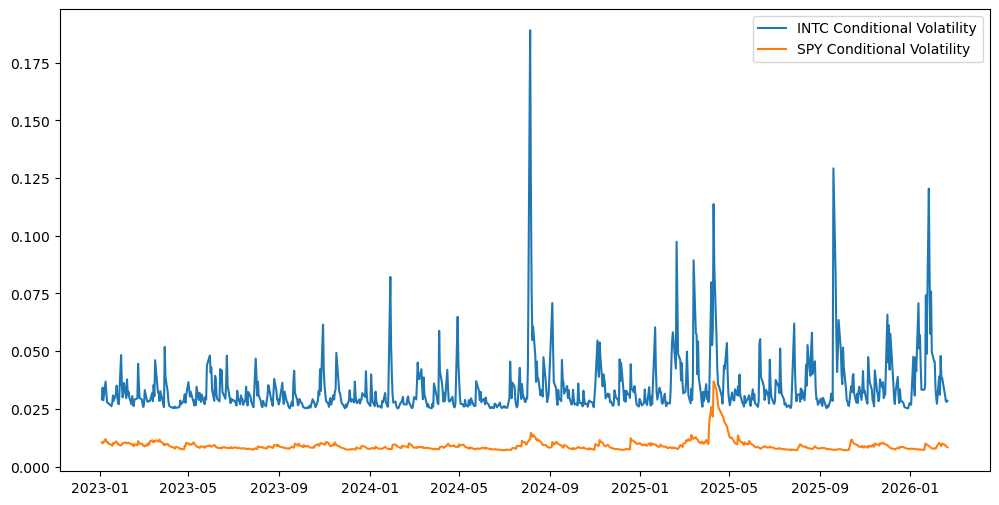

In [30]:
# plot volatility
plt.figure(figsize=(12, 6))
plt.plot(stock_res.conditional_volatility, label=f'{stock} Conditional Volatility')
plt.plot(index_res.conditional_volatility, label=f'{index} Conditional Volatility')
plt.legend()

Simulating Portfolios, 1 million in stock_portfolio, 1 million in index_portfolio initially

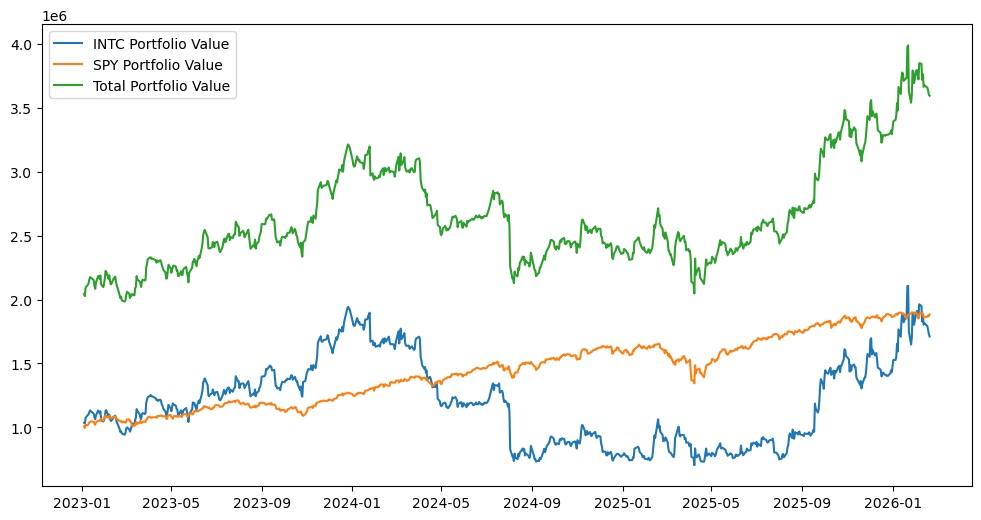

In [65]:
stock_daily_returns = stock_data['Close'].pct_change().dropna().squeeze()
index_daily_returns = index_data['Close'].pct_change().dropna().squeeze()

stock_portfolio = 1_000_000
index_portfolio = 1_000_000
total_portfolio = stock_portfolio + index_portfolio

stock_portfolio_values = stock_portfolio * (1 + stock_daily_returns).cumprod()
index_portfolio_values = index_portfolio * (1 + index_daily_returns).cumprod()
total_portfolio_values = stock_portfolio_values + index_portfolio_values

total_portfolio_daily_returns = total_portfolio_values.pct_change().dropna()

plt.figure(figsize=(12, 6))
plt.plot(stock_portfolio_values, label=f'{stock} Portfolio Value')
plt.plot(index_portfolio_values, label=f'{index} Portfolio Value')
plt.plot(total_portfolio_values, label='Total Portfolio Value')
plt.legend()

In [72]:
total_days = len(stock_daily_returns)
var_level = 0.99
var_index = int(total_days * (1 - var_level))

stock_daily_returns_sorted = stock_daily_returns.sort_values(ascending=False)
index_daily_returns_sorted = index_daily_returns.sort_values(ascending=False)
total_portfolio_daily_returns_sorted = total_portfolio_daily_returns.sort_values(ascending=False)

stock_portfolio_var = stock_portfolio * stock_daily_returns_sorted.iloc[var_index]
index_portfolio_var = index_portfolio * index_daily_returns_sorted.iloc[var_index]
total_portfolio_var = total_portfolio * total_portfolio_daily_returns_sorted.iloc[var_index]

print("-" * 50)
print(f"{stock} portfolio VaR at {var_level:.0%} confidence level: ${stock_portfolio_var:,.2f}")
print(f"{index} portfolio VaR at {var_level:.0%} confidence level: ${index_portfolio_var:,.2f}")
print(f"Total portfolio VaR at {var_level:.0%} confidence level: ${total_portfolio_var:,.2f}")

stock_portfolio_es = sum([stock_portfolio * ret for ret in stock_daily_returns[var_index + 1 :]]) / var_index
index_portfolio_es = sum([index_portfolio * ret for ret in index_daily_returns_sorted[var_index + 1 :]]) / var_index
total_portfolio_es = sum([total_portfolio * ret for ret in total_portfolio_daily_returns_sorted[var_index + 1 :]]) / var_index

print("-" * 50)
print(f"{stock} portfolio ES at {var_level:.0%} confidence level: ${stock_portfolio_es:,.2f}")
print(f"{index} portfolio ES at {var_level:.0%} confidence level: ${index_portfolio_es:,.2f}")
print(f"Total portfolio ES at {var_level:.0%} confidence level: ${total_portfolio_es:,.2f}")




--------------------------------------------------
INTC portfolio VaR at 99% confidence level: $101,874.49
SPY portfolio VaR at 99% confidence level: $20,790.60
Total portfolio VaR at 99% confidence level: $94,402.75
--------------------------------------------------
INTC portfolio ES at 99% confidence level: $125,425.96
SPY portfolio ES at 99% confidence level: $56,033.41
Total portfolio ES at 99% confidence level: $43,256.20
